# Credit Score Classification
Pada tahap awal dilakukan import seluruh library yang dibutuhkan selama proses eksplorasi data, preprocessing, pembangunan model machine learning, evaluasi model, serta visualisasi hasil.

Library yang digunakan meliputi Pandas dan NumPy untuk manipulasi data, Matplotlib dan Seaborn untuk visualisasi, serta Scikit-learn dan XGBoost untuk preprocessing, training model, dan evaluasi.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

## Load Dataset
Dataset dibaca menggunakan Pandas dan ditampilkan beberapa baris pertama untuk memahami struktur data yang akan digunakan dalam proses klasifikasi credit score.

In [24]:
df = pd.read_csv("/kaggle/input/datasets/abelnabel/uas-md/data_B.csv")
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


## Data Understanding
Tahap ini bertujuan untuk memahami karakteristik dataset dengan melihat:
- jumlah baris dan kolom,
- tipe data setiap fitur,
- statistik deskriptif,
- distribusi awal data.

Informasi ini digunakan sebagai dasar dalam menentukan proses preprocessing yang diperlukan.

In [25]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21244.000000,25000.000000,25000.000000,25000.000000,25000.000000,24510.000000,25000.000000,25000.000000
mean,12499.500000,4202.920107,16.189320,22.204800,72.883720,21.029360,27.477111,32.294362,1300.578910
std,7217.022701,3167.562787,113.979946,128.635884,464.533619,14.815959,191.841035,5.136061,7938.267492
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.257073,0.000000
25%,6249.750000,1634.214792,3.000000,4.000000,8.000000,10.000000,3.000000,28.007510,30.622965
50%,12499.500000,3118.399167,6.000000,5.000000,13.000000,18.000000,6.000000,32.276799,69.528976
75%,18749.250000,5968.797083,7.000000,7.000000,20.000000,28.000000,9.000000,36.553116,161.078485
max,24999.000000,15204.633333,1798.000000,1495.000000,5774.000000,67.000000,2587.000000,49.254983,82256.000000


## Feature Selection
Beberapa fitur dihapus karena tidak memiliki kontribusi terhadap prediksi credit score, seperti ID pelanggan maupun informasi identitas pribadi.

Fitur-fitur tersebut hanya berfungsi sebagai identifier sehingga berpotensi menambah noise pada model.

In [26]:
# Drop Irrelevant Features
drop_cols = ["ID", "Customer_ID", "Name", "SSN", "Month"]
df.drop(columns=drop_cols, inplace=True)

## Duplicate Handling
Dilakukan pemeriksaan terhadap data duplikat untuk memastikan setiap observasi hanya muncul satu kali.

Data duplikat dihapus agar model tidak mengalami bias akibat data yang berulang.

In [27]:
# Drop Duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates()

Duplicate rows: 0


## Data Type Conversion
Beberapa fitur numerik masih tersimpan dalam format string karena mengandung karakter khusus seperti koma, simbol, maupun teks.

Tahap ini membersihkan karakter yang tidak diperlukan dan mengubah seluruh fitur menjadi tipe numerik agar dapat diproses oleh model machine learning.

In [28]:
# Fix Data Type
def clean_numeric(col):
    col = col.astype(str)
    col = col.str.replace("_", "", regex=False)
    col = col.str.replace(",", "", regex=False)
    col = col.str.replace("$", "", regex=False)
    col = col.str.extract(r"([-]?\d+\.?\d*)")[0]
    return pd.to_numeric(col, errors="coerce")

numeric_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_cols:
    df[col] = clean_numeric(df[col])

## Feature Engineering
Fitur *Credit History Age* dikonversi dari format teks (tahun dan bulan) menjadi jumlah bulan sehingga dapat digunakan sebagai fitur numerik dalam proses training model.

In [29]:
# Handle Credit History Age
def convert_credit_history(age_str):
    if pd.isna(age_str):
        return np.nan
    years = int(age_str.split("Years")[0].strip())
    months = int(age_str.split("and")[1].split("Months")[0].strip())
    return years * 12 + months

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history)

## Invalid Value Handling
Dilakukan pengecekan terhadap nilai yang tidak valid, seperti nilai negatif pada fitur yang secara logika tidak mungkin bernilai negatif.

Nilai tersebut dianggap sebagai missing value sehingga akan ditangani pada tahap selanjutnya.

In [30]:
# Inconsistent data - invalid negative values
invalid_negative = [
    "Age",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Delay_from_due_date"
]

for col in invalid_negative:
    df.loc[df[col] < 0, col] = np.nan

## Missing Value Handling
Jumlah missing value dihitung terlebih dahulu sebelum dilakukan imputasi. Nilai numerik diisi menggunakan median karena lebih robust terhadap outlier, sedangkan fitur kategorikal diisi menggunakan modus agar informasi kategori tetap dipertahankan.

In [31]:
# Missing Value & Handling
missing_count = df.isnull().sum()
missing_percent = missing_count / len(df) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

print(missing_df[missing_df["Missing Count"] > 0])


num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

                         Missing Count  Missing %
Monthly_Inhand_Salary             3756     15.024
Type_of_Loan                      2848     11.392
Credit_History_Age                2292      9.168
Num_of_Delayed_Payment            1733      6.932
Amount_invested_monthly           1060      4.240
Changed_Credit_Limit               532      2.128
Num_Credit_Inquiries               490      1.960
Monthly_Balance                    301      1.204
Age                                217      0.868
Delay_from_due_date                154      0.616
Num_Bank_Accounts                    6      0.024


## Categorical Data Cleaning
Beberapa fitur kategorikal masih memiliki placeholder atau nilai tidak valid.

Placeholder tersebut diubah menjadi missing value kemudian dilakukan imputasi agar data kategorikal menjadi konsisten.

In [32]:
# Replace invalid placeholders in categorical columns
df["Occupation"] = df["Occupation"].replace("_______", np.nan)
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
df["Payment_Behaviour"] = df["Payment_Behaviour"].str.replace(r"[^a-zA-Z_ ]", "", regex=True)

# Handling missing categorical
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("Unknown")

## Outlier Treatment
Outlier ditangani menggunakan metode capping berdasarkan persentil agar nilai ekstrem tidak terlalu mempengaruhi proses pembelajaran model, namun tetap mempertahankan sebagian besar informasi pada data.

In [33]:
# Outlier
for col in num_cols:
    upper = df[col].quantile(0.95)
    lower = df[col].quantile(0.05)
    df[col] = np.clip(df[col], lower, upper)

## Correlation Analysis
Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik. Visualisasi ini membantu memahami keterkaitan antar variabel sekaligus mengidentifikasi kemungkinan adanya multikolinearitas.

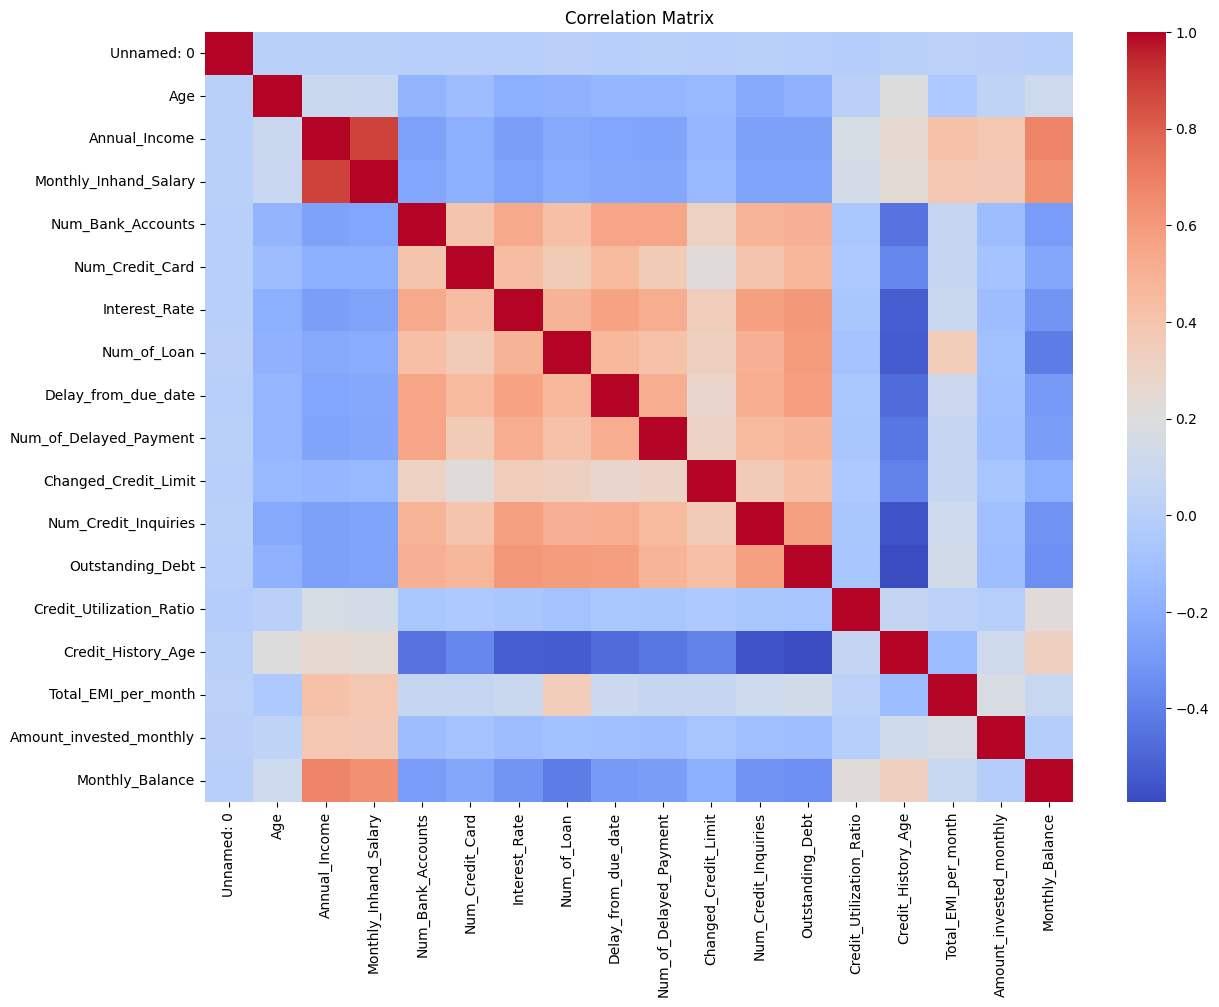

In [34]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Matrix")
plt.show()

In [35]:
print(df.isnull().sum().sum(), "missing values remaining")
df.shape
df.info()
df.describe()

0 missing values remaining
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  float64
 1   Age                       25000 non-null  float64
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  float64
 6   Num_Credit_Card           25000 non-null  float64
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              25000 non-null  object 
 10  Delay_from_due_date       25000 non-null  float64
 11  Num_of_Delayed_Payment    25000 non-null  float64
 12  Changed_Credit_Limit      25000 non-null  float64
 13  Num_Credit_Inquiries      25000 no

,Unnamed: 0,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12499.500000,33.851320,50796.701678,3963.650386,5.469400,5.694320,14.861640,3.371400,21.018160,13.491480,10.246455,5.843160,1397.337518,32.273383,222.532560,112.371708,235.772513,395.698087
std,7115.195885,10.816494,36775.797204,2694.577627,2.543989,2.040884,8.818182,2.427694,14.067224,5.925178,6.184595,3.798097,1078.186105,4.930503,91.830983,114.895863,267.745494,182.085781
min,1249.950000,17.000000,9766.965000,887.782083,1.000000,3.000000,2.000000,0.000000,3.000000,2.000000,1.199500,0.000000,118.580000,24.230471,68.000000,0.000000,33.292334,173.923378
25%,6249.750000,25.000000,19548.868750,1804.031667,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.420000,3.000000,563.310000,28.007510,153.000000,30.622965,78.286292,270.095087
50%,12499.500000,33.000000,37824.960000,3118.399167,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.370000,6.000000,1170.255000,32.276799,220.000000,69.528976,138.572608,336.618808
75%,18749.250000,42.000000,73020.540000,5390.500625,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.612500,9.000000,1925.940000,36.553116,293.000000,161.078485,258.267687,469.341916
max,23749.050000,54.000000,134270.756000,10368.906167,10.000000,10.000000,32.000000,8.000000,54.000000,24.000000,23.440500,13.000000,4034.530000,40.258586,380.000000,428.782069,1131.995982,854.645194


## Feature dan Target
Target klasifikasi adalah **Credit_Score** yang dikonversi menjadi label numerik. Dataset kemudian dipisahkan menjadi fitur (X) dan target (y), selanjutnya dibagi menjadi data training dan testing untuk proses evaluasi model.

In [36]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]
y = y.map({"Poor": 0, "Standard": 1, "Good": 2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Categorization
Fitur dipisahkan menjadi dua kelompok, yaitu fitur numerik dan fitur kategorikal. Pemisahan ini diperlukan karena masing-masing tipe data memerlukan teknik preprocessing yang berbeda.

In [37]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

## Preprocessing Pipeline
Seluruh proses preprocessing digabungkan ke dalam ColumnTransformer. Tahapan preprocessing meliputi:
- One-Hot Encoding untuk fitur kategorikal.
- Standard Scaling untuk fitur numerik.

Pipeline ini memastikan preprocessing dilakukan secara konsisten baik pada data training maupun data inferensi.

In [38]:
# Buat encoder
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

## Model Machine Learning yang Digunakan
Beberapa model digunakan untuk dibandingkan performanya, yaitu:
- Logistic Regression (baseline linear model)
- Random Forest Classifier (ensemble bagging)
- XGBoost Classifier (gradient boosting)

Setiap model diuji dalam dua skenario:
- **Baseline model (default parameter)**
- **Tuned model (hyperparameter tuning)**

Hyperparameter tuning dilakukan untuk meningkatkan performa model dengan mengoptimalkan parameter seperti:
- jumlah estimator
- depth pohon
- learning rate
- regularization parameter

In [39]:
# Random Forest Base Model
rf_base = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_base.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [40]:
# Random Forest Tuned
rf_tuned = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ))
])

rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, random_state=42))])

In [41]:
# XGBoost Base Model
xgb_base = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_base.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [42]:
# XGBoost Tuned
xgb_tuned = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [43]:
# Logistic Regression Base Model
log_base = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial"
    ))
])

log_base.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

In [44]:
# Logistic Regression Tuned
log_tuned = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        C=0.5,
        solver="lbfgs",
        multi_class="multinomial"
    ))
])

log_tuned.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(C=0.5, max_iter=1000,
                                    multi_class='multinomial'))])

# Model Evaluation
Seluruh model dievaluasi menggunakan data testing. Metrik evaluasi yang digunakan meliputi:
- Accuracy
- Precision
- Recall
- F1-Score

Keempat metrik tersebut memberikan gambaran menyeluruh terhadap kemampuan model dalam mengklasifikasikan credit score.

In [45]:
# EVALUATION
def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate(rf_base, "Random Forest Base")
evaluate(rf_tuned, "Random Forest Tuned")

evaluate(xgb_base, "XGBoost Base")
evaluate(xgb_tuned, "XGBoost Tuned")

evaluate(log_base, "LogReg Base")
evaluate(log_tuned, "LogReg Tuned")


===== Random Forest Base =====
Accuracy: 0.735
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      1440
           1       0.76      0.78      0.77      2651
           2       0.64      0.65      0.65       909

    accuracy                           0.73      5000
   macro avg       0.72      0.71      0.71      5000
weighted avg       0.74      0.73      0.73      5000


===== Random Forest Tuned =====
Accuracy: 0.6628
              precision    recall  f1-score   support

           0       0.64      0.76      0.69      1440
           1       0.85      0.54      0.66      2651
           2       0.49      0.85      0.62       909

    accuracy                           0.66      5000
   macro avg       0.66      0.72      0.66      5000
weighted avg       0.72      0.66      0.66      5000


===== XGBoost Base =====
Accuracy: 0.7228
              precision    recall  f1-score   support

           0       0.75      0.68      0.7

In [48]:
models = {
    "rf_base": rf_base,
    "rf_tuned": rf_tuned,
    "xgb_base": xgb_base,
    "xgb_tuned": xgb_tuned,
    "log_base": log_base,
    "log_tuned": log_tuned
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, average="weighted")
    results[name] = f1

results

sorted(results.items(), key=lambda x: x[1], reverse=True)

[('rf_base', 0.7347082273304778),
 ('xgb_tuned', 0.7250266692721853),
 ('xgb_base', 0.7227792516429601),
 ('rf_tuned', 0.6648140603878371),
 ('log_tuned', 0.5799237522570864),
 ('log_base', 0.5708173283140144)]

In [49]:
best_model_name = max(results, key=results.get)
best_model_name

best_model = models[best_model_name]
best_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

## Evaluation
Model Random Forest Base memberikan performa terbaik dengan accuracy 0.735, serta keseimbangan precision dan recall yang relatif stabil pada semua kelas.

Namun, pada model Random Forest Tuned, terjadi penurunan performa menjadi 0.6628, yang menunjukkan bahwa hyperparameter tuning yang dilakukan belum optimal dan justru menyebabkan model menjadi kurang general.

Model XGBoost Base dan Tuned menunjukkan performa yang cukup konsisten (sekitar 0.72–0.725), namun masih sedikit di bawah Random Forest Base.

Sementara itu, Logistic Regression memiliki performa paling rendah, terutama pada kelas minoritas (kelas 2), yang terlihat dari recall yang sangat kecil.

Jadi, berdasarkan hasil evaluasi, model terbaik adalah Random Forest Base karena memiliki:
- Accuracy tertinggi (0.735)
- Keseimbangan precision dan recall yang baik
- Performa stabil di semua kelas

Model ini dipilih sebagai final model untuk tahap selanjutnya.

## Confusion Matrix
Confusion Matrix digunakan untuk melihat performa klasifikasi secara lebih rinci.
Visualisasi ini menunjukkan jumlah prediksi benar maupun salah pada setiap kelas sehingga dapat diketahui pola kesalahan yang dilakukan oleh model.

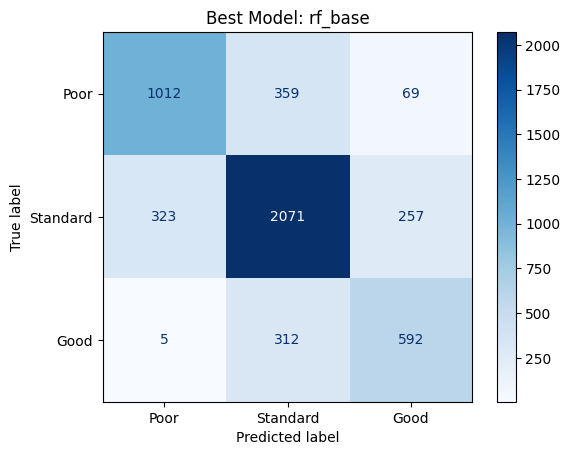

In [50]:
cm = confusion_matrix(y_test, best_model.predict(X_test))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Poor", "Standard", "Good"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title(f"Best Model: {best_model_name}")
plt.show()